Thư viện

In [4]:
import numpy as np
import pandas as pd #đọc đầu vào csv
import matplotlib.pyplot as plt #vẽ đồ thị
from scipy.fft import fft, fftfreq # biễu diễn trên miền tần số
from scipy.signal import spectrogram # biểu diễn tren miền thời gian tần số
from scipy.signal import butter, filtfilt #bandpass filter

định nghĩa tiền xử lý

In [5]:
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def detrend(data):
    return data - np.mean(data)

def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

def windowing(data, window_size, step_size):
    windows = []
    for start in range(0, len(data) - window_size + 1, step_size):
        windows.append(data[start:start + window_size])
    return np.array(windows)


Định nghĩa hàm trích xuất đặc trưng

In [6]:
def extract_features(window, loca=""): #loca: location of the sensor
    features = {}
    features[f'mean_{loca}'] = np.mean(window) #giá trị trung bình
    features[f'var_{loca}'] = np.var(window) #phương sai
    features[f'std_{loca}'] = np.std(window) #độ lệch chuẩn
    features[f'rms_{loca}'] = np.sqrt(np.mean(window**2)) #giá trị hiệu dụng
    features[f'max_{loca}'] = np.max(window)#giá trị lớn nhất
    features[f'ptp_{loca}'] = np.ptp(window) #peak to peak
    features[f'crest_{loca}']=np.max(np.abs(window)) / features[f'rms_{loca}'] #chỉ số đỉnh
    features[f'clearance_{loca}']=features[f'max_{loca}'] / np.mean(np.abs(window)) #chỉ số rõ ràng
    features[f'shape_{loca}']=features[f'crest_{loca}'] / features[f'clearance_{loca}'] #chỉ số hình dạng
    features[f'impulse_{loca}']=features[f'max_{loca}'] / np.mean(np.sqrt(np.abs(window))) #chỉ số xung
    return features

Trích data để vẽ đồ thị

In [7]:
df = pd.read_csv('0Nm_BPFI_03.csv')
dataplot= df.iloc[5000 : 15000, 0].values

Thông số đầu vào

In [8]:
fs= 25600  #tần số lấy mẫu
lowcut = 100  #tần số cắt thấp
highcut = 5000  #tần số cắt cao
window_size = 2**11  #số mẫu mỗi đoạn
step_size = int((2**11)/2)  #bước nhảy

Lặp lại cho tất cả các file và trích xuất đặc trưng

In [ ]:
files = {"0Nm_BPFI_03.csv": "BPFI_03",
        "2Nm_BPFI_03.csv": "BPFI_03",
        "4Nm_BPFI_03.csv": "BPFI_03",
        "0Nm_BPFI_10.csv": "BPFI_10",
        "2Nm_BPFI_10.csv": "BPFI_10",
        "4Nm_BPFI_10.csv": "BPFI_10",
        "0Nm_BPFO_03.csv": "BPFO_03",
        "2Nm_BPFO_03.csv": "BPFO_03",
        "4Nm_BPFO_03.csv": "BPFO_03",
        "0Nm_BPFO_10.csv": "BPFO_10",
        "2Nm_BPFO_10.csv": "BPFO_10",
        "4Nm_BPFO_10.csv": "BPFO_10",
        "0Nm_Misalign_01.csv": "Misalign_01",
        "2Nm_Misalign_01.csv": "Misalign_01",
        "4Nm_Misalign_01.csv": "Misalign_01",
        "0Nm_Misalign_03.csv": "Misalign_03",
        "2Nm_Misalign_03.csv": "Misalign_03",
        "4Nm_Misalign_03.csv": "Misalign_03",
        "0Nm_Unbalance_0583mg.csv": "Unbalance_0583mg",
        "2Nm_Unbalance_0583mg.csv": "Unbalance_0583mg",
        "4Nm_Unbalance_0583mg.csv": "Unbalance_0583mg",
        "0Nm_Unbalance_1169mg.csv": "Unbalance_1169mg",
        "2Nm_Unbalance_1169mg.csv": "Unbalance_1169mg",
        "4Nm_Unbalance_1169mg.csv": "Unbalance_1169mg",
        "0Nm_Normal.csv": "Normal",
        "2Nm_Normal.csv": "Normal_2Nm",
        "4Nm_Normal.csv": "Normal_4Nm"
        }
channels = ["Xa", " Ya", " Xb", " Yb"]
all_features = []

for file, label in files.items():
    df = pd.read_csv(file) 
    file_features = []

    # Duyệt từng kênh
    for i, channel in enumerate(channels):
        data = df.iloc[:, i].values
        # tiền xử lý
            #lọc 
        filtered_data = bandpass_filter(data, lowcut, highcut, fs)
            # loại bỏ xu hướng
        detrended_data = detrend(filtered_data)
            # chuẩn hóa
        normalized_data = normalize(detrended_data)
            # chia đoạn
        windows = windowing(normalized_data, window_size, step_size)

        # trích xuất đặc trưng từng window
        ch_feature_list = [extract_features(window, loca =channel) for window in windows]
        ch_features = pd.DataFrame(ch_feature_list)

        # gom vào danh sách chung
        if len(file_features) == 0:
            file_features = ch_features
        else:
            file_features = pd.concat([file_features, ch_features], axis=1)

         # thêm nhãn
    file_features["label"] = label
    all_features.append(file_features)

# Xuất kết quả
all_features_df = pd.concat(all_features, ignore_index=True)
all_features_df.to_csv("features.csv", index=False)

Miền thời gian

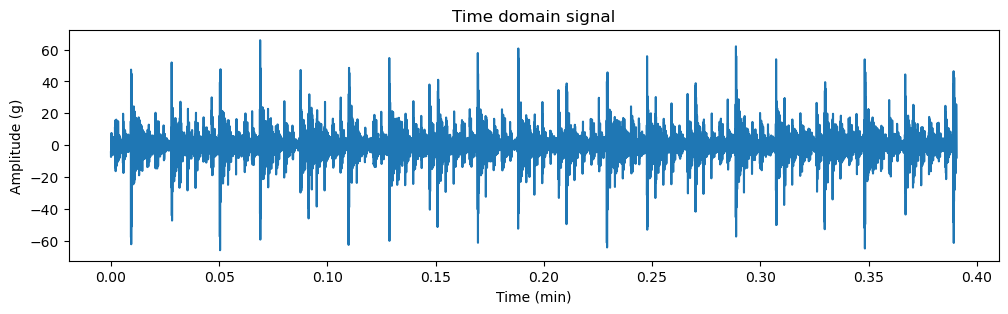

In [8]:
time = np.arange(len(dataplot)) / fs
plt.figure(figsize=(12, 3))
plt.plot(time,dataplot)
plt.xlabel('Time (min)')
plt.ylabel('Amplitude (g)')
plt.title('Time domain signal')
plt.show()

Miền tần số

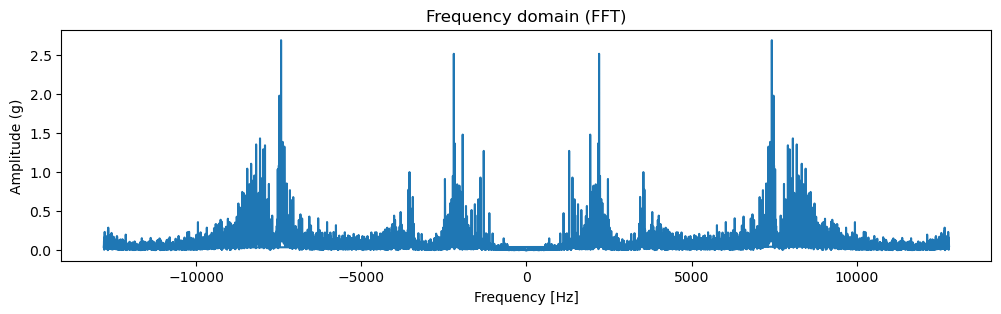

In [9]:

N = len(dataplot)          # số điểm FFT
yf = fft(dataplot)
xf = fftfreq(N, 1/fs)[:N]  # trục tần số (Hz)

plt.figure(figsize=(12, 3))
plt.plot(xf, 2.0/N * np.abs(yf[:N]))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude (g)")
plt.title("Frequency domain (FFT)")
plt.show()

Miền thời gian-tần số

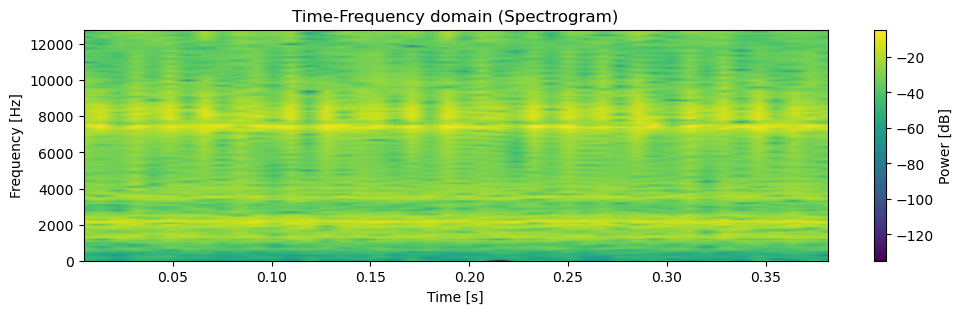

In [10]:
f, t, Sxx = spectrogram(dataplot, fs)
plt.figure(figsize=(12, 3))
plt.pcolormesh(t, f, 10*np.log10(Sxx), shading='gouraud')
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")
plt.title("Time-Frequency domain (Spectrogram)")
plt.colorbar(label="Power [dB]")
plt.show()
